# 03 - 日线行情采集

本 Notebook 完成以下任务：
1. 同步交易日历（增量更新的基础）
2. 历史数据初始化（5 年）
3. 增量更新演示
4. 数据抽样验证
5. Baostock 备用数据源演示

---

## 设计方案

### 增量更新机制
1. 先同步 `trade_calendar`（SSE 交易日历）
2. 对每只股票，用日历比对 `stock_daily` 表，找出缺失的交易日
3. 只拉取缺失日期范围的数据，Upsert 写入

### 双数据源
- **Tushare**（主）：`pro.daily()` 接口
- **Baostock**（备）：`query_history_k_data_plus()` 接口，Tushare 不可用时降级

## 1. 同步交易日历

In [1]:
from invest_model.db import get_engine
from invest_model.sources.tushare_client import TushareClient
from invest_model.collectors.calendar_collector import CalendarCollector
from invest_model.repositories.calendar_repo import CalendarRepository

engine = get_engine()
ts_client = TushareClient()

cal_collector = CalendarCollector(ts_client, engine)
cal_collector.collect()

# 验证
cal_repo = CalendarRepository(engine)
recent = cal_repo.get_trade_dates("20260301", "20260406")
print(f"\n2026年3月以来的交易日（部分）: {recent[:10]}...")
print(f"最新日历日期: {cal_repo.get_latest_date()}")

17:16:39 | INFO    | Tushare 客户端初始化完成


17:16:39 | INFO    | 采集交易日历: 20210101 ~ 20261231


17:16:39 | INFO    | 获取到 2191 条日历记录，其中交易日 1454 天


17:16:39 | INFO    | 写入 trade_calendar: 2191 条



2026年3月以来的交易日（部分）: ['20260302', '20260303', '20260304', '20260305', '20260306', '20260309', '20260310', '20260311', '20260312', '20260313']...
最新日历日期: 20261231


## 2. 历史数据初始化（5 年）

对股票池中所有标的拉取 5 年日线历史。首次运行耗时较长。

In [2]:
from invest_model.collectors.stock_daily_collector import StockDailyCollector
from invest_model.repositories.stock_pool_repo import StockPoolRepository

pool_repo = StockPoolRepository(engine)
stock_codes = pool_repo.get_pool_codes("core")
print(f"待采集个股: {stock_codes}")

daily_collector = StockDailyCollector(ts_client, engine)
results = daily_collector.collect_history(stock_codes)

print("\n采集结果:")
for code, count in results.items():
    status = f"{count} 条" if count >= 0 else "失败"
    print(f"  {code}: {status}")

17:16:40 | INFO    | [日线历史] 进度: 1/5 (20%)


待采集个股: ['000333.SZ', '000858.SZ', '300750.SZ', '600519.SH', '601318.SH']


17:16:40 | INFO    | 000333.SZ: 写入 1210 条日线 (20210408~20260407)


17:16:40 | INFO    | [日线历史] 进度: 2/5 (40%)


17:16:40 | INFO    | 000858.SZ: 写入 1210 条日线 (20210408~20260407)


...

17:16:41 | INFO    | 600519.SH: 写入 1210 条日线 (20210408~20260407)


17:16:41 | INFO    | [日线历史] 进度: 5/5 (100%)


17:16:42 | INFO    | 601318.SH: 写入 1210 条日线 (20210408~20260407)


17:16:42 | INFO    | 日线历史采集完成: 5 只股票, 共 6050 条



采集结果:
  000333.SZ: 1210 条
  000858.SZ: 1210 条
  300750.SZ: 1210 条
  600519.SH: 1210 条
  601318.SH: 1210 条


## 3. 增量更新演示

In [3]:
# 增量更新（只拉取缺失的交易日）
incr_results = daily_collector.collect_incremental(stock_codes)

print("增量更新结果:")
for code, count in incr_results.items():
    if count > 0:
        print(f"  {code}: 新增 {count} 条")
    elif count == 0:
        print(f"  {code}: 已是最新")
    else:
        print(f"  {code}: 失败")

17:16:42 | INFO    | 日线增量完成: 5 只, 新增 0 条


增量更新结果:
  000333.SZ: 已是最新
  000858.SZ: 已是最新
  300750.SZ: 已是最新
  600519.SH: 已是最新
  601318.SH: 已是最新


## 4. 数据抽样验证

In [4]:
from invest_model.repositories.stock_daily_repo import StockDailyRepository

daily_repo = StockDailyRepository(engine)

# 查看贵州茅台最新 10 条
df = daily_repo.get_daily("600519.SH", "20260301", "20260406")
print(f"600519.SH 最近行情 ({len(df)} 条):")
print(df.tail(10).to_string(index=False))

600519.SH 最近行情 (25 条):
     code trade_date    open    high     low   close  pre_close  change  pct_chg volume      amount          created_at
600519.SH   20260323 1433.33 1435.00 1400.03 1408.07    1445.00  -36.93  -2.5557   None 6669708.665 2026-04-07 17:15:08
600519.SH   20260324 1416.00 1417.59 1400.18 1407.33    1408.07   -0.74  -0.0526   None 4017694.387 2026-04-07 17:15:08
600519.SH   20260325 1410.11 1417.87 1401.01 1410.27    1407.33    2.94   0.2089   None 3677905.549 2026-04-07 17:15:08
600519.SH   20260326 1409.00 1413.90 1400.30 1401.18    1410.27   -9.09  -0.6446   None 3243387.502 2026-04-07 17:15:08
600519.SH   20260327 1400.00 1426.00 1396.66 1416.02    1401.18   14.84   1.0591   None 4257499.781 2026-04-07 17:15:08
600519.SH   20260330 1407.00 1431.00 1402.52 1420.00    1416.02    3.98   0.2811   None 4060684.934 2026-04-07 17:15:08
600519.SH   20260331 1468.00 1479.93 1448.41 1450.00    1420.00   30.00   2.1127   None 9015486.797 2026-04-07 17:15:08
600519.SH   20260

In [5]:
# 统计各股票数据量
import pandas as pd

stats = daily_repo.read_sql(
    "SELECT code, COUNT(*) as cnt, MIN(trade_date) as start_date, MAX(trade_date) as end_date "
    "FROM stock_daily GROUP BY code ORDER BY code"
)
print("各股票数据统计:")
print(stats.to_string(index=False))

各股票数据统计:
     code  cnt start_date end_date
000333.SZ 1210   20210408 20260407
000858.SZ 1210   20210408 20260407
300750.SZ 1210   20210408 20260407
600519.SH 1210   20210408 20260407
601318.SH 1210   20210408 20260407


## 6. 收盘价与成交量图（Matplotlib）

下面用采集结果直接画图，便于在 Notebook 里查看趋势（非交互 K 线，侧重可读与离线执行）。

/tmp/ipykernel_634848/1992001194.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  vol = plot_df["volume"].fillna(0)


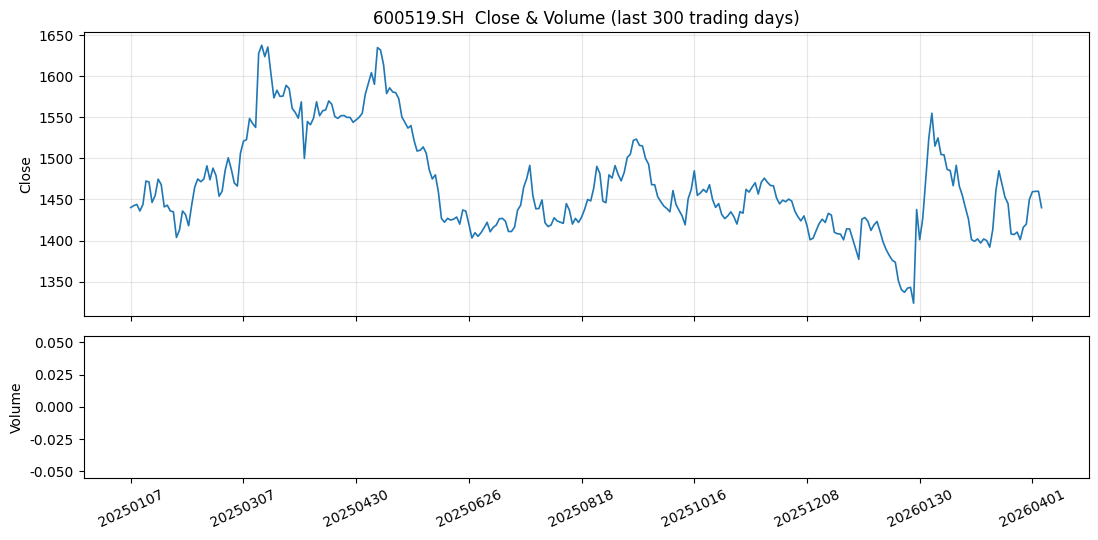

In [6]:
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei', 'SimHei', 'Arial Unicode MS', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
import matplotlib.pyplot as plt

plot_df = daily_repo.get_daily("600519.SH", "20200101", "20991231")
if plot_df.empty:
    print("No kline data, skip chart")
else:
    plot_df = plot_df.dropna(subset=["close"]).tail(300).reset_index(drop=True)
    tail_n = len(plot_df)
    x = range(tail_n)
    vol = plot_df["volume"].fillna(0)
    fig, axes = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
    axes[0].plot(x, plot_df["close"], color="#1f77b4", linewidth=1.2)
    axes[0].set_ylabel("Close")
    axes[0].set_title(f"600519.SH  Close & Volume (last {tail_n} trading days)")
    axes[0].grid(True, alpha=0.3)
    axes[1].bar(x, vol, color="steelblue", alpha=0.65, width=1.0)
    axes[1].set_ylabel("Volume")
    step = max(1, tail_n // 8)
    axes[1].set_xticks(list(x)[::step])
    axes[1].set_xticklabels(plot_df["trade_date"].astype(str).iloc[::step], rotation=25)
    plt.tight_layout()
    plt.show()

## 5. Baostock 备用数据源

In [7]:
from invest_model.sources.baostock_client import BaostockClient

bao_client = BaostockClient()

# 用 Baostock 拉取相同股票做交叉验证
bao_df = bao_client.get_stock_daily("600519.SH", "20260301", "20260406")
print(f"Baostock 获取 600519.SH: {len(bao_df)} 条")
if not bao_df.empty:
    print(bao_df.tail(5).to_string(index=False))

17:16:43 | INFO    | Baostock 客户端初始化完成


login success!


Baostock 获取 600519.SH: 25 条
     code trade_date    open    high     low   close  pre_close  change  pct_chg   volume       amount
600519.SH   20260330 1407.00 1431.00 1402.52 1420.00    1416.02    3.98   0.2811 28684.59 4.060685e+09
600519.SH   20260331 1468.00 1479.93 1448.41 1450.00    1420.00   30.00   2.1127 61690.66 9.015487e+09
600519.SH   20260401 1464.49 1469.99 1452.88 1459.44    1450.00    9.44   0.6510 29125.14 4.256185e+09
600519.SH   20260402 1459.44 1464.88 1452.10 1459.88    1459.44    0.44   0.0301 21064.37 3.071810e+09
600519.SH   20260403 1459.54 1469.96 1455.00 1460.00    1459.88    0.12   0.0082 20193.73 2.953993e+09


## 完成

日线数据已采集完毕（5 年历史 + 增量更新机制就绪）。

继续 `04_fundamentals.ipynb` 采集财务指标数据。